# INFO-6147-(01)-26W Deep Learning with Pytorch

## Project: This is for UI

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**Description:**

This project is aim to allow user upload the photos of food and describe what the food tastes like. It will be helpful when traveling or when people wants to try international food, but not having a person to explain to you what that is.
Here comes this AI project, to assist people on observing new foods.

## Setup Environment

In [16]:
!pip install streamlit groq qrcode
# download cloudflared
!curl -L https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb -o cloudflared.deb
!dpkg -i cloudflared.deb

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.4M  100 18.4M    0     0  17.3M      0  0:00:01  0:00:01 --:--:-- 71.4M
(Reading database ... 118198 files and directories currently installed.)
Preparing to unpack cloudflared.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


## Confirm files

In [18]:
from dotenv import load_dotenv
import os

#go to Folder
os.chdir('/content')
!ls  # confirm files

load_dotenv()  # read .env
api_key = os.getenv("GROQ_API_KEY")

app.py	cloudflared.deb  food_best.pth	sample_data


## Kill previous server

In [19]:
!pkill -f streamlit
!pkill -f cloudflared

import time
time.sleep(5)
print("✅ Server processes cleaned up.")

✅ Server processes cleaned up.



## Execute the UI file

⏳ wait Streamlit activate (10 sec)...
🌐 get url and Log...
Log: 2026-04-16T17:04:35Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
Log: 2026-04-16T17:04:35Z INF Requesting new quick Tunnel on trycloudflare.com...
Log: 2026-04-16T17:04:38Z INF +--------------------------------------------------------------------------------------------+
Log: 2026-04-16T17:04:38Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |

═

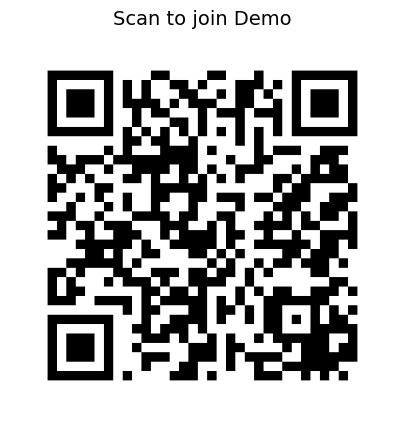

Log: 2026-04-16T17:04:38Z INF |  https://artificial-meets-individually-island.trycloudflare.com                            |
Log: 2026-04-16T17:04:38Z INF +--------------------------------------------------------------------------------------------+
Log: 2026-04-16T17:04:38Z INF Cannot determine default configuration path. No file [config.yml config.yaml] in [~/.cloudflared ~/.cloudflare-warp ~/cloudflare-warp /etc/cloudflared /usr/local/etc/cloudflared]
Log: 2026-04-16T17:04:38Z INF Version 2026.3.0 (Checksum 4a9e50e6d6d798e90fcd01933151a90bf7edd99a0a55c28ad18f2e16263a5c30)
Log: 2026-04-16T17:04:38Z INF GOOS: linux, GOVersion: go1.24.13, GoArch: amd64
Log: 2026-04-16T17:04:38Z INF Settings: map[ha-connections:1 protocol:quic url:http://localhost:8501]
Log: 2026-04-16T17:04:38Z INF cloudflared will not automatically update if installed by a package manager.
Log: 2026-04-16T17:04:38Z INF Generated Connector ID: 01f36c99-d6d0-4815-b2ae-f7367fa8cdfa
Log: 2026-04-16T17:04:38Z INF Initial p

KeyboardInterrupt: 

In [21]:
import re
import qrcode
import subprocess
import threading
import webbrowser
import matplotlib.pyplot as plt
from dotenv import load_dotenv


# activate streamlit
threading.Thread(target=lambda: subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501"]), daemon=True).start()

print("⏳ wait Streamlit activate (10 sec)...")
time.sleep(10)


# activate tunnel
p = subprocess.Popen(["cloudflared", "tunnel", "--url", "http://localhost:8501"],
                     stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

print("🌐 get url and Log...")

# get log
found_url = False
for line in p.stdout:
    # check url
    if not found_url:
        match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', line)
        if match:
          url = match.group(0)
          print("\n" + "═"*60)
          print(f"🚀  SYSTEM LIVE: {url}")
          print("═"*60 + "\n")
          found_url = True

          # QR Code
          qr = qrcode.make(url)
          plt.figure(figsize=(5,5))
          plt.imshow(qr, cmap='gray')
          plt.axis('off')
          plt.title("Scan to join Demo", fontsize=14)
          plt.show()

    # print log for debug
    if "error" in line.lower() or "exception" in line.lower():
        print(f"❌ detech error: {line.strip()}")
    else:
        # print each line for debug
        print(f"Log: {line.strip()}")

In [ ]:
!ls -lh food_best.pth

In [11]:
!ls -a

.   app.py	     .config  food_best.pth	  sample_data
..  cloudflared.deb  .env     .ipynb_checkpoints
